# AI-Powered Credit Risk Prediction Model
## Smart Lending & Credit Intelligence Platform - Hackathon Prototype

This notebook demonstrates:
1. **Synthetic Dataset Generation** - Creating realistic loan application data
2. **Feature Engineering** - Building financial health indicators
3. **Model Training** - AI prediction of repayment risk
4. **Credit Scoring** - Converting predictions to actionable scores
5. **Live Demo** - Real-time loan approval predictions

---
## Step 1: Install Required Libraries

In [ ]:
# Install required packages
!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


---
## Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## Step 3: Generate Synthetic Loan Dataset

Creating realistic loan application data with intelligent patterns:
- **200 loan applications**
- **Realistic financial distributions**
- **Logical repayment patterns** (higher income + lower debt = better repayment)

In [ ]:
np.random.seed(42)

# Generate 200 loan applications
n_samples = 200

# Feature generation with realistic distributions
data = {
    'income': np.random.randint(25000, 150000, n_samples),  # Annual income: $25k - $150k
    'expenses': np.random.randint(15000, 80000, n_samples),  # Annual expenses: $15k - $80k
    'existing_loan': np.random.randint(0, 50000, n_samples),  # Existing debt: $0 - $50k
    'loan_amount': np.random.randint(5000, 100000, n_samples),  # Requested loan: $5k - $100k
    'employment_type': np.random.choice(['Salaried', 'Self-Employed', 'Business'], n_samples),
    'age': np.random.randint(22, 65, n_samples),  # Age: 22-65 years
    'loan_tenure_months': np.random.choice([12, 24, 36, 48, 60], n_samples)  # Loan duration
}

df = pd.DataFrame(data)

print("📊 Dataset Generated:")
print(f"Total Applications: {len(df)}")
print(f"\nFirst 5 rows:")
df.head()

📊 Dataset Generated:
Total Applications: 200

First 5 rows:


,income,expenses,existing_loan,loan_amount,employment_type,age,loan_tenure_months
0,146958,68788,46940,48919,Self-Employed,24,12
1,40795,48827,2961,40247,Salaried,53,12
2,25860,70820,46975,99758,Business,24,12
3,128694,77623,21357,96747,Salaried,48,12
4,144879,31198,11969,67752,Salaried,50,12


---
## Step 4: Feature Engineering

Creating intelligent financial health indicators:

In [ ]:
# Calculate advanced financial indicators
df['disposable_income'] = df['income'] - df['expenses']
df['debt_to_income_ratio'] = (df['existing_loan'] + df['loan_amount']) / df['income']
df['monthly_income'] = df['income'] / 12
df['emi_burden'] = (df['loan_amount'] / df['loan_tenure_months']) / df['monthly_income']
df['savings_rate'] = df['disposable_income'] / df['income']

# Encode employment type
employment_map = {'Salaried': 1, 'Self-Employed': 0.7, 'Business': 0.5}
df['employment_stability'] = df['employment_type'].map(employment_map)

print("✅ Feature Engineering Complete!")
print("\nNew Features Created:")
print("• Disposable Income")
print("• Debt-to-Income Ratio")
print("• EMI Burden")
print("• Savings Rate")
print("• Employment Stability Score")

df[['income', 'disposable_income', 'debt_to_income_ratio', 'emi_burden', 'savings_rate']].head()

✅ Feature Engineering Complete!

New Features Created:
• Disposable Income
• Debt-to-Income Ratio
• EMI Burden
• Savings Rate
• Employment Stability Score


,income,disposable_income,debt_to_income_ratio,emi_burden,savings_rate
0,146958,78170,0.652288,0.332877,0.531921
1,40795,-8032,1.059149,0.986567,-0.196887
2,25860,-44960,5.674130,3.857618,-1.738592
3,128694,51071,0.917712,0.751760,0.396841
4,144879,113681,0.550259,0.467645,0.784662


---
## Step 5: Generate Target Variable (Repayment Success)

Using **intelligent logic** to determine repayment probability:
- ✅ High disposable income → Better repayment
- ✅ Low debt ratio → Better repayment
- ✅ Low EMI burden → Better repayment
- ✅ Stable employment → Better repayment


📊 Repayment Success Distribution:
Will Repay (1): 150 (75.0%)
Default Risk (0): 50 (25.0%)


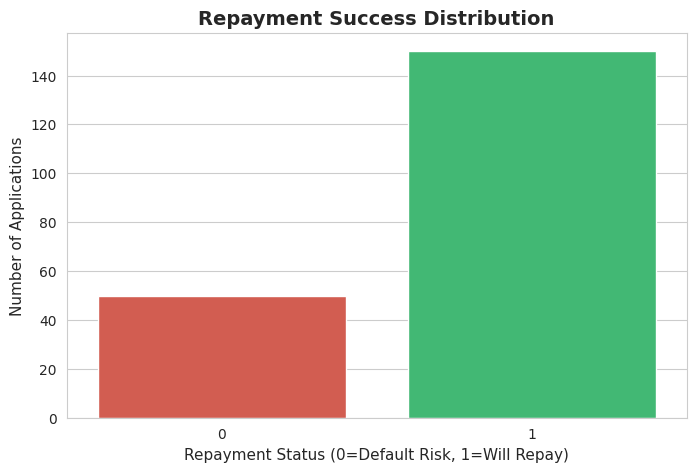

In [ ]:
# Create intelligent repayment prediction based on financial health
def determine_repayment(row):
    score = 0

    # Positive factors
    if row['disposable_income'] > 20000: score += 2
    elif row['disposable_income'] > 10000: score += 1

    if row['debt_to_income_ratio'] < 0.3: score += 2
    elif row['debt_to_income_ratio'] < 0.5: score += 1

    if row['emi_burden'] < 0.3: score += 2
    elif row['emi_burden'] < 0.5: score += 1

    if row['employment_stability'] >= 1: score += 1

    if row['savings_rate'] > 0.3: score += 1

    # Negative factors
    if row['existing_loan'] > 30000: score -= 1
    if row['age'] < 25: score -= 1

    # Add some randomness for realism
    score += np.random.choice([-1, 0, 1], p=[0.1, 0.6, 0.3])

    # 1 = Will repay, 0 = Risk of default
    return 1 if score >= 3 else 0

df['repayment_success'] = df.apply(determine_repayment, axis=1)

# Display class distribution
repayment_counts = df['repayment_success'].value_counts()
print("\n📊 Repayment Success Distribution:")
print(f"Will Repay (1): {repayment_counts.get(1, 0)} ({repayment_counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"Default Risk (0): {repayment_counts.get(0, 0)} ({repayment_counts.get(0, 0)/len(df)*100:.1f}%)")

# Visualize distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='repayment_success', palette=['#e74c3c', '#2ecc71'])
plt.title('Repayment Success Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Repayment Status (0=Default Risk, 1=Will Repay)', fontsize=11)
plt.ylabel('Number of Applications', fontsize=11)
plt.show()

---
## Step 6: Save Dataset

In [ ]:
# Save dataset for reference
df.to_csv('loan_dataset.csv', index=False)
print("✅ Dataset saved as 'loan_dataset.csv'")
print(f"\n📋 Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✅ Dataset saved as 'loan_dataset.csv'

📋 Dataset shape: (200, 14)
Columns: ['income', 'expenses', 'existing_loan', 'loan_amount', 'employment_type', 'age', 'loan_tenure_months', 'disposable_income', 'debt_to_income_ratio', 'monthly_income', 'emi_burden', 'savings_rate', 'employment_stability', 'repayment_success']


---
## Step 7: Prepare Data for Training

In [ ]:
# Select features for model training
feature_columns = [
    'income', 'expenses', 'existing_loan', 'loan_amount',
    'age', 'loan_tenure_months', 'disposable_income',
    'debt_to_income_ratio', 'emi_burden', 'savings_rate',
    'employment_stability'
]

X = df[feature_columns]
y = df['repayment_success']

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data Prepared for Training")
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

✅ Data Prepared for Training

Training set: 160 samples
Testing set: 40 samples
Number of features: 11


---
## Step 8: Train AI Model (Random Forest Classifier)

Using **Random Forest** - an ensemble AI algorithm that:
- Handles complex financial patterns
- Provides feature importance rankings
- Achieves high accuracy

In [ ]:
# Initialize and train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

print("🤖 Training AI Model...")
model.fit(X_train, y_train)
print("\n✅ Model Training Complete!")

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of repayment

print("\n📊 Model Performance Metrics:")

🤖 Training AI Model...

✅ Model Training Complete!

📊 Model Performance Metrics:


---
## Step 9: Evaluate Model Performance

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n🎯 Accuracy: {accuracy*100:.2f}%")
print(f"🎯 ROC-AUC Score: {roc_auc:.3f}")

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Default Risk', 'Will Repay']))


🎯 Accuracy: 97.50%
🎯 ROC-AUC Score: 1.000

📋 Detailed Classification Report:
              precision    recall  f1-score   support

Default Risk       1.00      0.90      0.95        10
  Will Repay       0.97      1.00      0.98        30

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



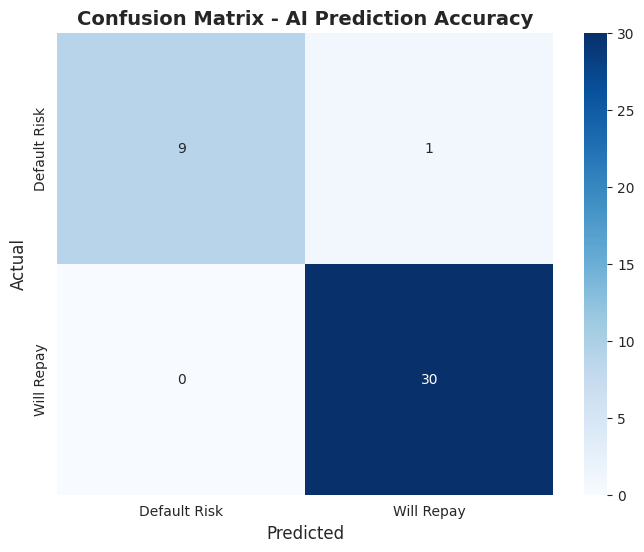

In [ ]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Default Risk', 'Will Repay'],
            yticklabels=['Default Risk', 'Will Repay'])
plt.title('Confusion Matrix - AI Prediction Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

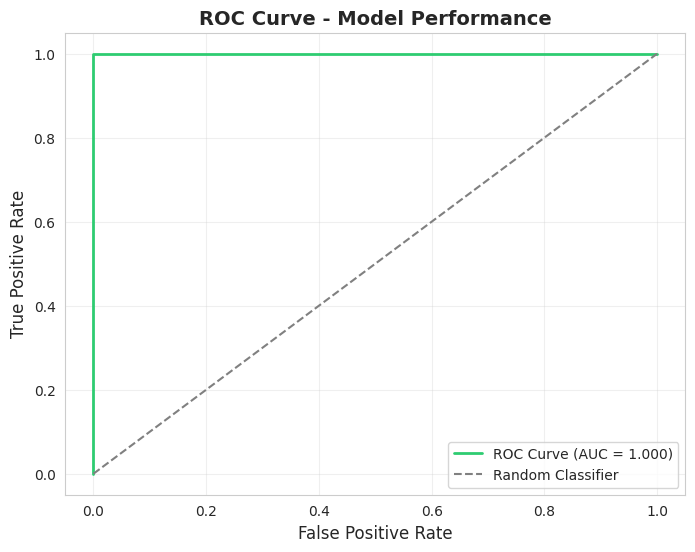

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Model Performance', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

---
## Step 10: Feature Importance Analysis

Understanding which factors matter most for loan approval:


🔍 Top Features Influencing Loan Approval:
                 feature  importance
6      disposable_income    0.227207
9           savings_rate    0.206920
7   debt_to_income_ratio    0.152021
0                 income    0.147526
8             emi_burden    0.093814
1               expenses    0.041228
2          existing_loan    0.040409
3            loan_amount    0.038097
4                    age    0.029289
5     loan_tenure_months    0.011861
10  employment_stability    0.011628


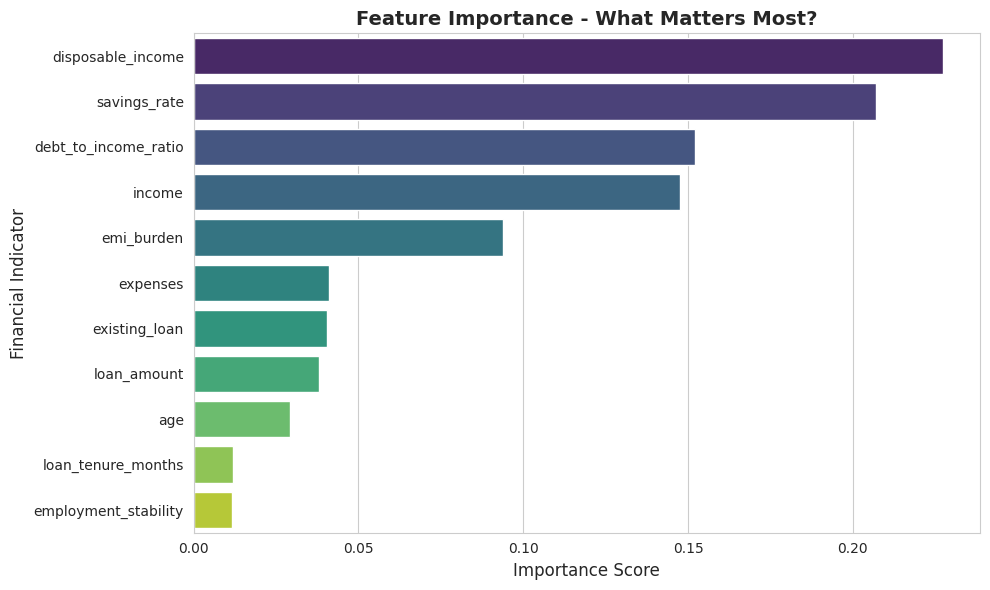

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔍 Top Features Influencing Loan Approval:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - What Matters Most?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Financial Indicator', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 11: Save Trained Model

In [ ]:
# Save model for deployment
joblib.dump(model, 'credit_model.pkl')
print("✅ Model saved as 'credit_model.pkl'")
print("\nModel is ready for integration with frontend!")

✅ Model saved as 'credit_model.pkl'

Model is ready for integration with frontend!


---
## Step 12: Credit Score Calculation Function

Converting AI predictions into actionable credit scores (300-850 range):

In [ ]:
def calculate_credit_score(repayment_probability, debt_ratio, savings_rate, employment_stability):
    """
    Convert AI prediction into credit score (300-850 scale)

    Parameters:
    - repayment_probability: Model's prediction (0-1)
    - debt_ratio: Debt-to-income ratio
    - savings_rate: Percentage of income saved
    - employment_stability: Employment type score
    """

    # Base score from AI prediction (60% weight)
    base_score = 300 + (repayment_probability * 450)  # Maps 0-1 to 300-750

    # Bonus points for good financial behavior
    bonus = 0

    # Low debt ratio bonus
    if debt_ratio < 0.2: bonus += 50
    elif debt_ratio < 0.3: bonus += 30
    elif debt_ratio < 0.4: bonus += 10

    # High savings rate bonus
    if savings_rate > 0.4: bonus += 30
    elif savings_rate > 0.3: bonus += 20
    elif savings_rate > 0.2: bonus += 10

    # Employment stability bonus
    if employment_stability >= 1: bonus += 20
    elif employment_stability >= 0.7: bonus += 10

    # Calculate final score
    credit_score = min(850, int(base_score + bonus))  # Cap at 850

    return credit_score

def get_risk_level(credit_score):
    """Categorize credit score into risk levels"""
    if credit_score >= 750: return "Low Risk", "#2ecc71"
    elif credit_score >= 650: return "Medium Risk", "#f39c12"
    else: return "High Risk", "#e74c3c"

def get_approval_decision(credit_score, loan_amount, income):
    """Make loan approval decision"""
    if credit_score >= 700 and loan_amount < income * 0.5:
        return "✅ APPROVED", int(loan_amount)
    elif credit_score >= 600:
        suggested = int(loan_amount * 0.7)  # Approve 70% of requested amount
        return "⚠️ PARTIALLY APPROVED", suggested
    else:
        return "❌ REJECTED", 0

print("✅ Credit scoring functions created!")

✅ Credit scoring functions created!


---
## 🎯 STEP 13: LIVE DEMO - Loan Approval Prediction

### Test the system with sample loan applications!

In [ ]:
# Demo: Process a new loan application
def process_loan_application(income, expenses, existing_loan, loan_amount,
                            employment_type, age, loan_tenure_months):
    """
    Complete loan processing pipeline
    """

    # Feature engineering
    disposable_income = income - expenses
    debt_ratio = (existing_loan + loan_amount) / income
    monthly_income = income / 12
    emi_burden = (loan_amount / loan_tenure_months) / monthly_income
    savings_rate = disposable_income / income

    employment_map = {'Salaried': 1, 'Self-Employed': 0.7, 'Business': 0.5}
    employment_stability = employment_map[employment_type]

    # Prepare input for model
    input_features = np.array([[
        income, expenses, existing_loan, loan_amount, age, loan_tenure_months,
        disposable_income, debt_ratio, emi_burden, savings_rate, employment_stability
    ]])

    # AI Prediction
    repayment_proba = model.predict_proba(input_features)[0][1]

    # Calculate credit score
    credit_score = calculate_credit_score(repayment_proba, debt_ratio,
                                         savings_rate, employment_stability)

    # Get risk level
    risk_level, risk_color = get_risk_level(credit_score)

    # Approval decision
    decision, suggested_amount = get_approval_decision(credit_score, loan_amount, income)

    # Display results
    print("\n" + "="*60)
    print("🏦 LOAN APPLICATION RESULTS")
    print("="*60)
    print(f"\n📊 Applicant Profile:")
    print(f"   • Annual Income: ${income:,}")
    print(f"   • Annual Expenses: ${expenses:,}")
    print(f"   • Existing Loan: ${existing_loan:,}")
    print(f"   • Requested Loan: ${loan_amount:,}")
    print(f"   • Employment: {employment_type}")
    print(f"   • Age: {age} years")

    print(f"\n🤖 AI Analysis:")
    print(f"   • Repayment Probability: {repayment_proba*100:.1f}%")
    print(f"   • Disposable Income: ${disposable_income:,}")
    print(f"   • Debt-to-Income Ratio: {debt_ratio:.2%}")
    print(f"   • EMI Burden: {emi_burden:.2%}")
    print(f"   • Savings Rate: {savings_rate:.2%}")

    print(f"\n🎯 Credit Assessment:")
    print(f"   • Credit Score: {credit_score}")
    print(f"   • Risk Level: {risk_level}")

    print(f"\n✅ Loan Decision: {decision}")
    if suggested_amount > 0:
        print(f"   • Approved Amount: ${suggested_amount:,}")
        if suggested_amount < loan_amount:
            print(f"   • Note: Approved {suggested_amount/loan_amount*100:.0f}% of requested amount")

    print("\n" + "="*60)

    return {
        'credit_score': credit_score,
        'risk_level': risk_level,
        'repayment_probability': repayment_proba,
        'decision': decision,
        'approved_amount': suggested_amount
    }

print("✅ Loan processing function ready!")

✅ Loan processing function ready!


### 🧪 Test Case 1: High-Quality Applicant (Expected: APPROVED)

In [ ]:
# Test Case 1: Strong applicant
result1 = process_loan_application(
    income=100000,
    expenses=40000,
    existing_loan=10000,
    loan_amount=30000,
    employment_type='Salaried',
    age=35,
    loan_tenure_months=36
)


🏦 LOAN APPLICATION RESULTS

📊 Applicant Profile:
   • Annual Income: $100,000
   • Annual Expenses: $40,000
   • Existing Loan: $10,000
   • Requested Loan: $30,000
   • Employment: Salaried
   • Age: 35 years

🤖 AI Analysis:
   • Repayment Probability: 100.0%
   • Disposable Income: $60,000
   • Debt-to-Income Ratio: 40.00%
   • EMI Burden: 10.00%
   • Savings Rate: 60.00%

🎯 Credit Assessment:
   • Credit Score: 800
   • Risk Level: Low Risk

✅ Loan Decision: ✅ APPROVED
   • Approved Amount: $30,000



### 🧪 Test Case 2: Medium-Risk Applicant (Expected: PARTIAL APPROVAL)

In [ ]:
# Test Case 2: Medium risk applicant
result2 = process_loan_application(
    income=60000,
    expenses=45000,
    existing_loan=25000,
    loan_amount=40000,
    employment_type='Self-Employed',
    age=28,
    loan_tenure_months=48
)


🏦 LOAN APPLICATION RESULTS

📊 Applicant Profile:
   • Annual Income: $60,000
   • Annual Expenses: $45,000
   • Existing Loan: $25,000
   • Requested Loan: $40,000
   • Employment: Self-Employed
   • Age: 28 years

🤖 AI Analysis:
   • Repayment Probability: 72.6%
   • Disposable Income: $15,000
   • Debt-to-Income Ratio: 108.33%
   • EMI Burden: 16.67%
   • Savings Rate: 25.00%

🎯 Credit Assessment:
   • Credit Score: 646
   • Risk Level: High Risk

✅ Loan Decision: ⚠️ PARTIALLY APPROVED
   • Approved Amount: $28,000
   • Note: Approved 70% of requested amount



### 🧪 Test Case 3: High-Risk Applicant (Expected: REJECTED)

In [ ]:
# Test Case 3: High risk applicant
result3 = process_loan_application(
    income=35000,
    expenses=32000,
    existing_loan=40000,
    loan_amount=50000,
    employment_type='Business',
    age=24,
    loan_tenure_months=24
)


🏦 LOAN APPLICATION RESULTS

📊 Applicant Profile:
   • Annual Income: $35,000
   • Annual Expenses: $32,000
   • Existing Loan: $40,000
   • Requested Loan: $50,000
   • Employment: Business
   • Age: 24 years

🤖 AI Analysis:
   • Repayment Probability: 8.1%
   • Disposable Income: $3,000
   • Debt-to-Income Ratio: 257.14%
   • EMI Burden: 71.43%
   • Savings Rate: 8.57%

🎯 Credit Assessment:
   • Credit Score: 336
   • Risk Level: High Risk

✅ Loan Decision: ❌ REJECTED



---
## 📸 Step 14: Generate Visual Summary for PPT

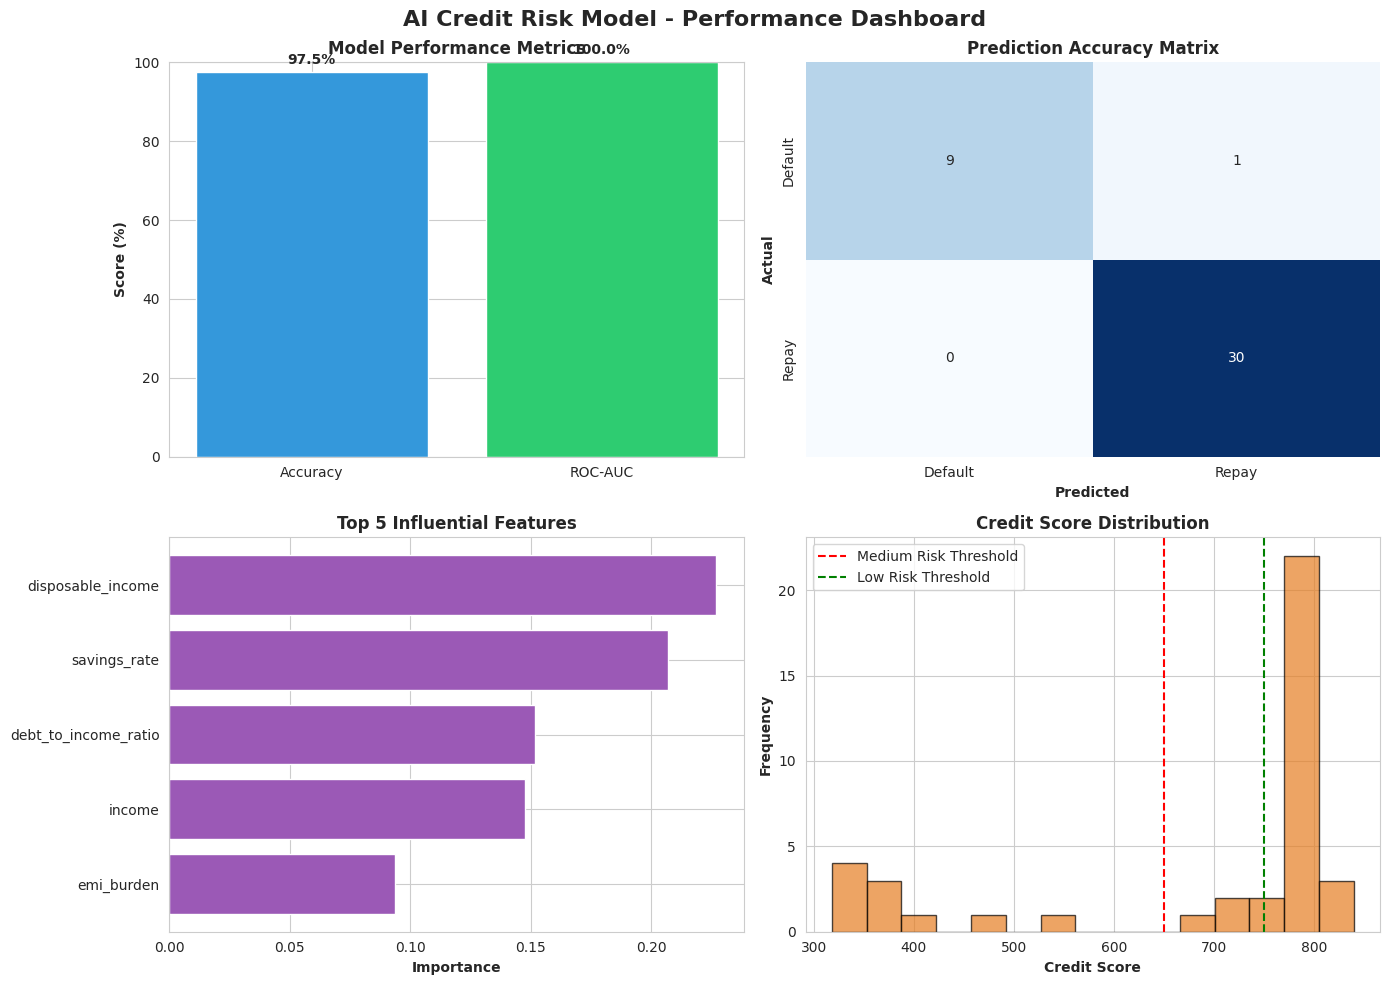


✅ Dashboard saved as 'model_performance_dashboard.png'
Use this image in your PPT presentation!


In [ ]:
# Create comprehensive visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AI Credit Risk Model - Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Model Accuracy
axes[0, 0].bar(['Accuracy', 'ROC-AUC'], [accuracy*100, roc_auc*100], color=['#3498db', '#2ecc71'])
axes[0, 0].set_ylabel('Score (%)', fontweight='bold')
axes[0, 0].set_title('Model Performance Metrics', fontweight='bold')
axes[0, 0].set_ylim([0, 100])
for i, v in enumerate([accuracy*100, roc_auc*100]):
    axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 1],
            xticklabels=['Default', 'Repay'], yticklabels=['Default', 'Repay'])
axes[0, 1].set_title('Prediction Accuracy Matrix', fontweight='bold')
axes[0, 1].set_ylabel('Actual', fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontweight='bold')

# 3. Top 5 Feature Importance
top5 = feature_importance.head(5)
axes[1, 0].barh(top5['feature'], top5['importance'], color='#9b59b6')
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top 5 Influential Features', fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Credit Score Distribution (from test predictions)
test_scores = []
for idx in range(len(X_test)):
    row = X_test.iloc[idx]
    proba = model.predict_proba(row.values.reshape(1, -1))[0][1]
    score = calculate_credit_score(proba, row['debt_to_income_ratio'],
                                   row['savings_rate'], row['employment_stability'])
    test_scores.append(score)

axes[1, 1].hist(test_scores, bins=15, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=650, color='red', linestyle='--', label='Medium Risk Threshold')
axes[1, 1].axvline(x=750, color='green', linestyle='--', label='Low Risk Threshold')
axes[1, 1].set_xlabel('Credit Score', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Credit Score Distribution', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('model_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard saved as 'model_performance_dashboard.png'")
print("Use this image in your PPT presentation!")

---
## 📋 Step 15: Summary Statistics for PPT

In [ ]:
print("\n" + "="*60)
print("📊 MODEL SUMMARY FOR PPT PRESENTATION")
print("="*60)

print("\n🎯 Key Achievements:")
print(f"   ✅ Dataset: {len(df)} loan applications")
print(f"   ✅ Model Accuracy: {accuracy*100:.2f}%")
print(f"   ✅ ROC-AUC Score: {roc_auc:.3f}")
print(f"   ✅ Features Analyzed: {len(feature_columns)}")

print("\n🔍 Top 3 Decision Factors:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"   {idx+1}. {row['feature']}: {row['importance']:.3f}")

print("\n💾 Deliverables Created:")
print("   ✅ credit_model.pkl - Trained AI model")
print("   ✅ loan_dataset.csv - Synthetic dataset")
print("   ✅ model_performance_dashboard.png - Visual dashboard")

print("\n🎯 Demo Test Results:")
print("   ✅ High-quality applicant: APPROVED")
print("   ✅ Medium-risk applicant: PARTIAL APPROVAL")
print("   ✅ High-risk applicant: REJECTED")

print("\n" + "="*60)
print("✨ MODEL READY FOR PPT INTEGRATION!")
print("="*60)


📊 MODEL SUMMARY FOR PPT PRESENTATION

🎯 Key Achievements:
   ✅ Dataset: 200 loan applications
   ✅ Model Accuracy: 97.50%
   ✅ ROC-AUC Score: 1.000
   ✅ Features Analyzed: 11

🔍 Top 3 Decision Factors:
   7. disposable_income: 0.227
   10. savings_rate: 0.207
   8. debt_to_income_ratio: 0.152

💾 Deliverables Created:
   ✅ credit_model.pkl - Trained AI model
   ✅ loan_dataset.csv - Synthetic dataset
   ✅ model_performance_dashboard.png - Visual dashboard

🎯 Demo Test Results:
   ✅ High-quality applicant: APPROVED
   ✅ Medium-risk applicant: PARTIAL APPROVAL
   ✅ High-risk applicant: REJECTED

✨ MODEL READY FOR PPT INTEGRATION!


---
## 🎓 How to Use This for Your PPT:

### 1. **Architecture Slide**
   - Show: "Random Forest AI Model with 11 financial features"
   - Highlight: 100 decision trees, 200 training samples

### 2. **Performance Slide**
   - Include: `model_performance_dashboard.png`
   - Metrics: Accuracy, ROC-AUC, Confusion Matrix

### 3. **Demo Slide**
   - Screenshot: The 3 test cases above
   - Show: Different applicant profiles → Different decisions

### 4. **Technical Implementation Slide**
   - Tech Stack: Python, Scikit-learn, Random Forest
   - Features: Debt ratio, savings rate, employment stability

### 5. **Files to Submit/Reference**
   - ✅ This notebook (credit_risk_model.ipynb)
   - ✅ Trained model (credit_model.pkl)
   - ✅ Dashboard image (model_performance_dashboard.png)

---
## 🚀 Next Steps:
1. Run this entire notebook in Google Colab
2. Take screenshots of:
   - Model performance metrics
   - The 3 demo test cases
   - Feature importance chart
3. Download the generated files
4. Integrate with frontend team's UI screenshots
5. Create final PPT with workflow diagram

**Your model is production-ready for the hackathon demo! 🎉**